In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import PowerTransformer
import seaborn as sns
import matplotlib.pyplot as plt

# CSV 파일 경로
star_file_path = './data/gaia_star_below_g_mag_7.csv'


# CSV 파일을 읽어서 DataFrame으로 변환
star_df = pd.read_csv(star_file_path)

print("data_shape : ", star_df.shape)
print(star_df.info())

data_shape :  (20032, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20032 entries, 0 to 20031
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ra                            20032 non-null  float64
 1   dec                           20032 non-null  float64
 2   parallax                      19591 non-null  float64
 3   phot_g_mean_flux              20032 non-null  float64
 4   phot_g_mean_mag               20032 non-null  float64
 5   phot_bp_mean_flux             20032 non-null  float64
 6   phot_bp_mean_mag              20032 non-null  float64
 7   phot_rp_mean_flux             20032 non-null  float64
 8   phot_rp_mean_mag              20032 non-null  float64
 9   phot_bp_rp_excess_factor      20032 non-null  float64
 10  radial_velocity               16204 non-null  float64
 11  phot_variable_flag            20032 non-null  object 
 12  classprob_dsc_combmod_quasar  2003

### 데이터 전처리 - 결측치 제거

In [2]:
# 분석에 불필요한 행 제거
star_df_befor_drop = star_df.drop(columns=['ra', 'dec', 'phot_g_mean_flux', 'phot_bp_mean_flux', 'phot_rp_mean_flux', 'phot_bp_rp_excess_factor', 'classprob_dsc_combmod_quasar', 'classprob_dsc_combmod_galaxy', 'classprob_dsc_combmod_star', 'phot_variable_flag'])

'''
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
star_df_befor_drop = pd.DataFrame(imputer.fit_transform(star_df_befor_drop), columns=star_df_befor_drop.columns)
'''

# 결측치 있는 데이터 row 제거
star_df_clean = star_df_befor_drop.dropna().reset_index(drop=True)

# 결측치가 있는 row만 추출
star_df_missing_gspphot = star_df_befor_drop[star_df_befor_drop[['teff_gspphot', 'logg_gspphot', 'mh_gspphot', 'distance_gspphot', 'azero_gspphot', 'ag_gspphot']].isna().any(axis=1)]
star_df_missing_parallax = star_df_befor_drop[star_df_befor_drop[['parallax']].isna().any(axis=1)]
star_df_missing_radial_velocity = star_df_befor_drop[star_df_befor_drop[['radial_velocity']].isna().any(axis=1)]


In [3]:
cols = ['teff_gspphot'] + [col for col in star_df_clean.columns if col != 'teff_gspphot']
star_df_clean = star_df_clean[cols]

cols = ['radial_velocity'] + [col for col in star_df_clean.columns if col != 'radial_velocity']
star_df_clean = star_df_clean[cols]

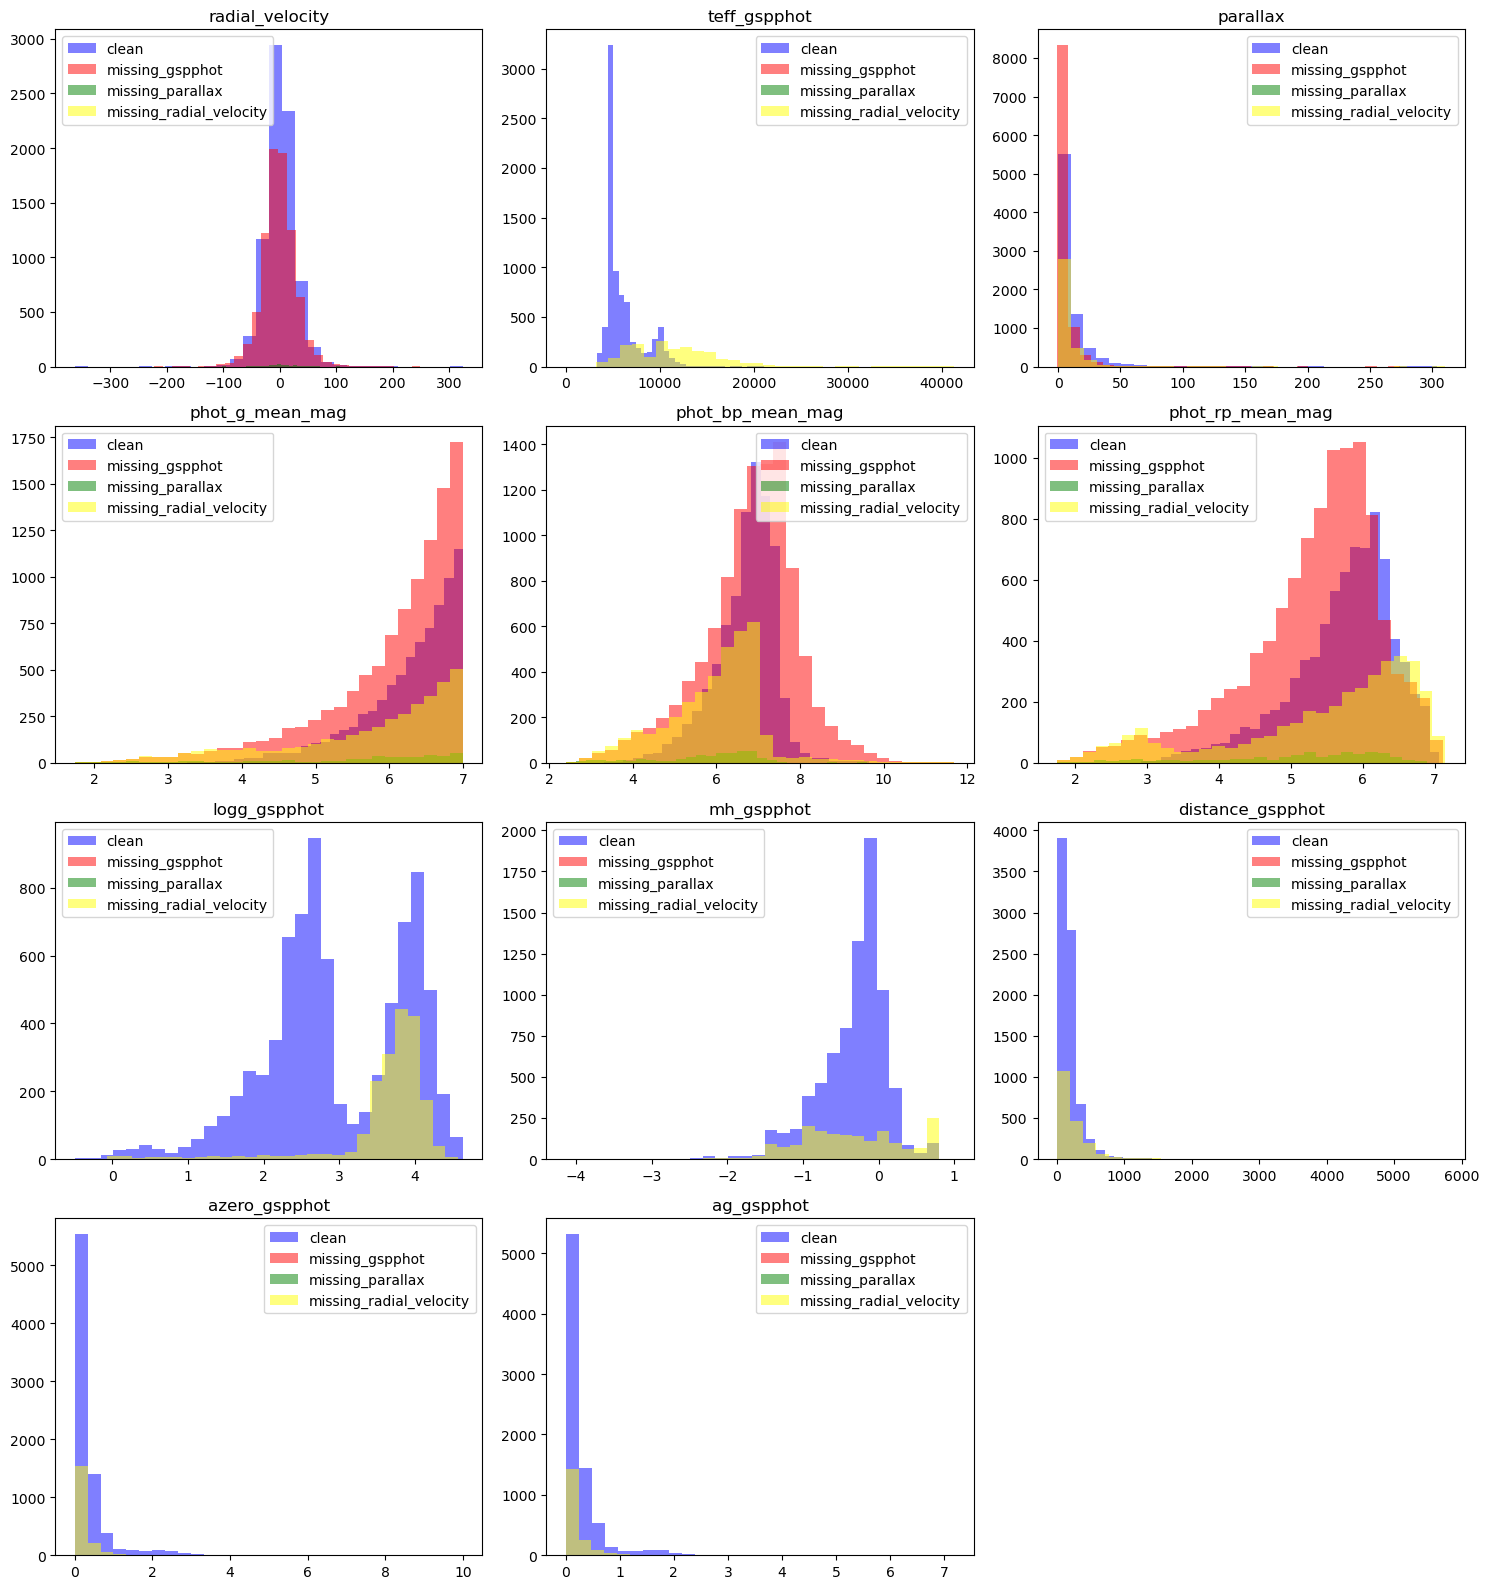

In [4]:
columns = star_df_clean.columns

n_cols = 3  
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten() 

for i, col in enumerate(columns):
    ax = axes[i]
    
    ax.hist(star_df_clean[col].dropna(), bins=30, alpha=0.5, label='clean', color='blue')
    ax.hist(star_df_missing_gspphot[col].dropna(), bins=30, alpha=0.5, label='missing_gspphot', color='red')
    ax.hist(star_df_missing_parallax[col].dropna(), bins=30, alpha=0.5, label='missing_parallax', color='green')
    ax.hist(star_df_missing_radial_velocity[col].dropna(), bins=30, alpha=0.5, label='missing_radial_velocity', color='yellow')
    
    ax.set_title(col)
    ax.legend()


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 데이터 전처리 - 파생변수 생성

In [5]:
#상대등급 -> 절대등급 = m−5log10(d/10) 
star_df_clean['phot_g_mean_mag'] = star_df_clean['phot_g_mean_mag'] - 5*np.log10(star_df_clean['distance_gspphot']/10)
star_df_clean['phot_bp_mean_mag'] = star_df_clean['phot_bp_mean_mag'] - 5*np.log10(star_df_clean['distance_gspphot']/10)
star_df_clean['phot_rp_mean_mag'] = star_df_clean['phot_rp_mean_mag'] - 5*np.log10(star_df_clean['distance_gspphot']/10)

### 데이터 전처리 후 결과 확인

In [6]:
# 데이터 확인
print('data_shape : ',star_df_clean.shape)

# 데이터 타입 확인
print(star_df_clean.info())

data_shape :  (7855, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7855 entries, 0 to 7854
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   radial_velocity   7855 non-null   float64
 1   teff_gspphot      7855 non-null   float64
 2   parallax          7855 non-null   float64
 3   phot_g_mean_mag   7855 non-null   float64
 4   phot_bp_mean_mag  7855 non-null   float64
 5   phot_rp_mean_mag  7855 non-null   float64
 6   logg_gspphot      7855 non-null   float64
 7   mh_gspphot        7855 non-null   float64
 8   distance_gspphot  7855 non-null   float64
 9   azero_gspphot     7855 non-null   float64
 10  ag_gspphot        7855 non-null   float64
dtypes: float64(11)
memory usage: 675.2 KB
None


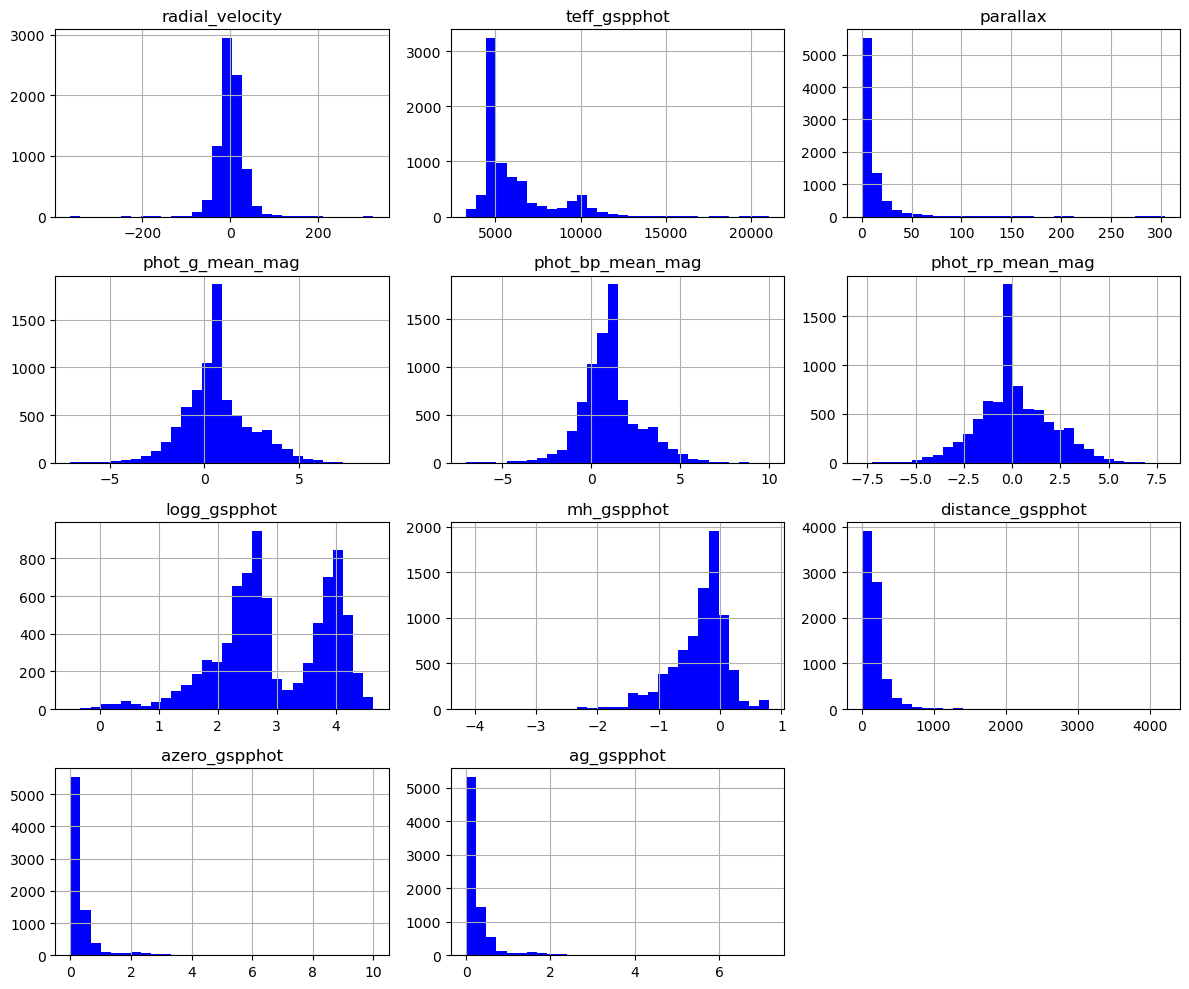

In [7]:
# 모든 수치형 컬럼에 대해 히스토그램 그리기
star_df_clean.hist(bins=30, figsize=(12, 10), color='blue') 
plt.tight_layout()
plt.savefig('star original data')
plt.show()

In [8]:
# 변환하지 않을 칼럼 원본 복사
star_df_clean_yeojohnson = star_df_clean[['radial_velocity','teff_gspphot']].copy()

#분포 변환할 칼럼
target_cols = ['parallax', 
               'phot_g_mean_mag',
               'phot_bp_mean_mag',
               'phot_rp_mean_mag',
               'logg_gspphot',
               'mh_gspphot',
               'distance_gspphot',
               'azero_gspphot',
               'ag_gspphot'
              ] 

# 분포변환 할 데이터 복사
star_df_clean_subset = star_df_clean[target_cols].copy()

# yeo-johnson 변환 (standard scaler 적용 X)
pt = PowerTransformer(method='yeo-johnson', standardize=False)
transformed = pt.fit_transform(star_df_clean_subset)

# 결과를 DataFrame으로 변환
star_df_clean_transformed = pd.DataFrame(transformed, columns=[col for col in star_df_clean_subset.columns], index=star_df_clean_subset.index)

# 변환 결과를 원본 복사본에 추가
star_df_clean_yeojohnson = star_df_clean_yeojohnson.join(star_df_clean_transformed)

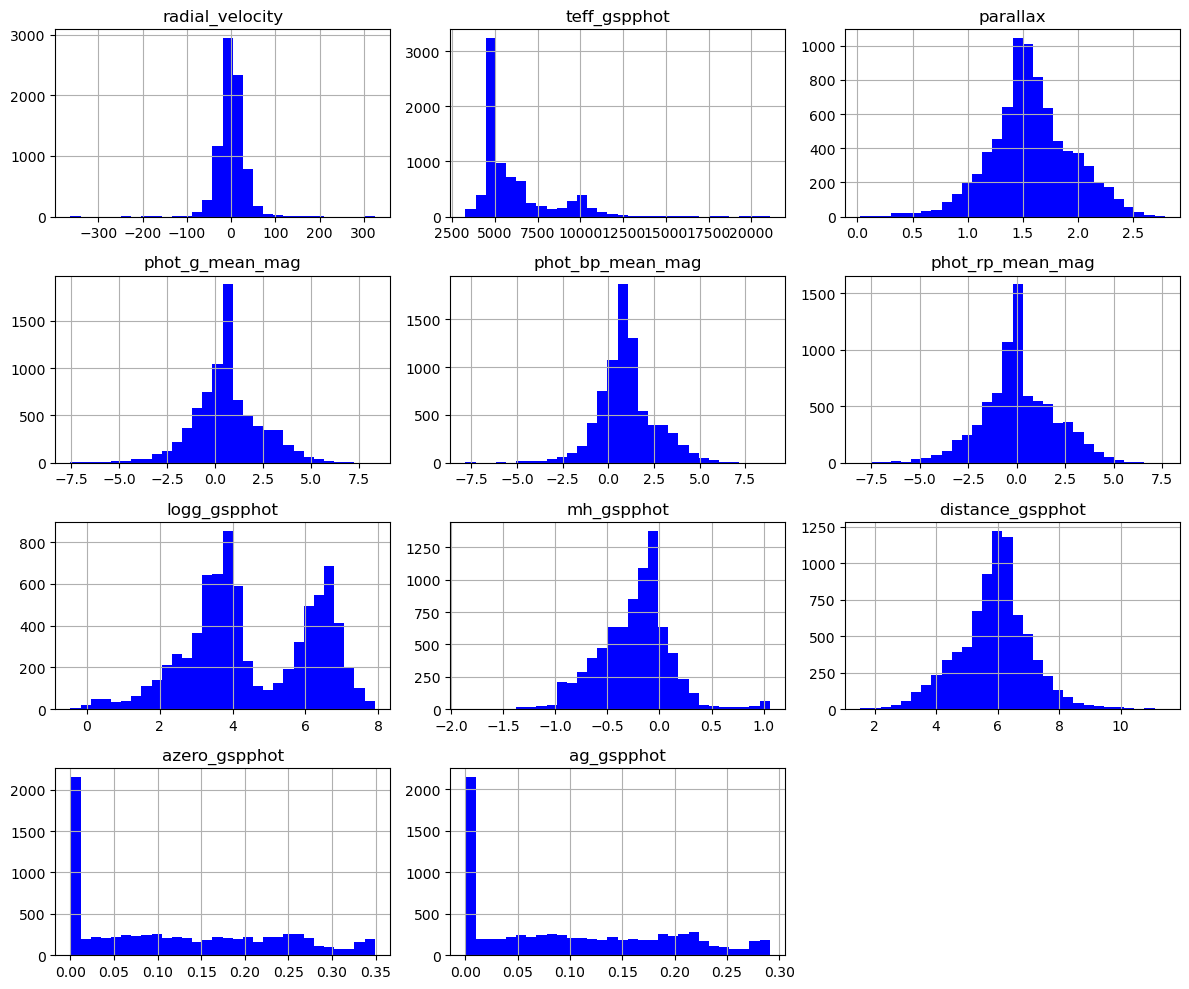

In [9]:
star_df_clean_yeojohnson.hist(bins=30, figsize=(12, 10), color='blue')
plt.tight_layout()
plt.savefig('star preprocessed data')
plt.show()

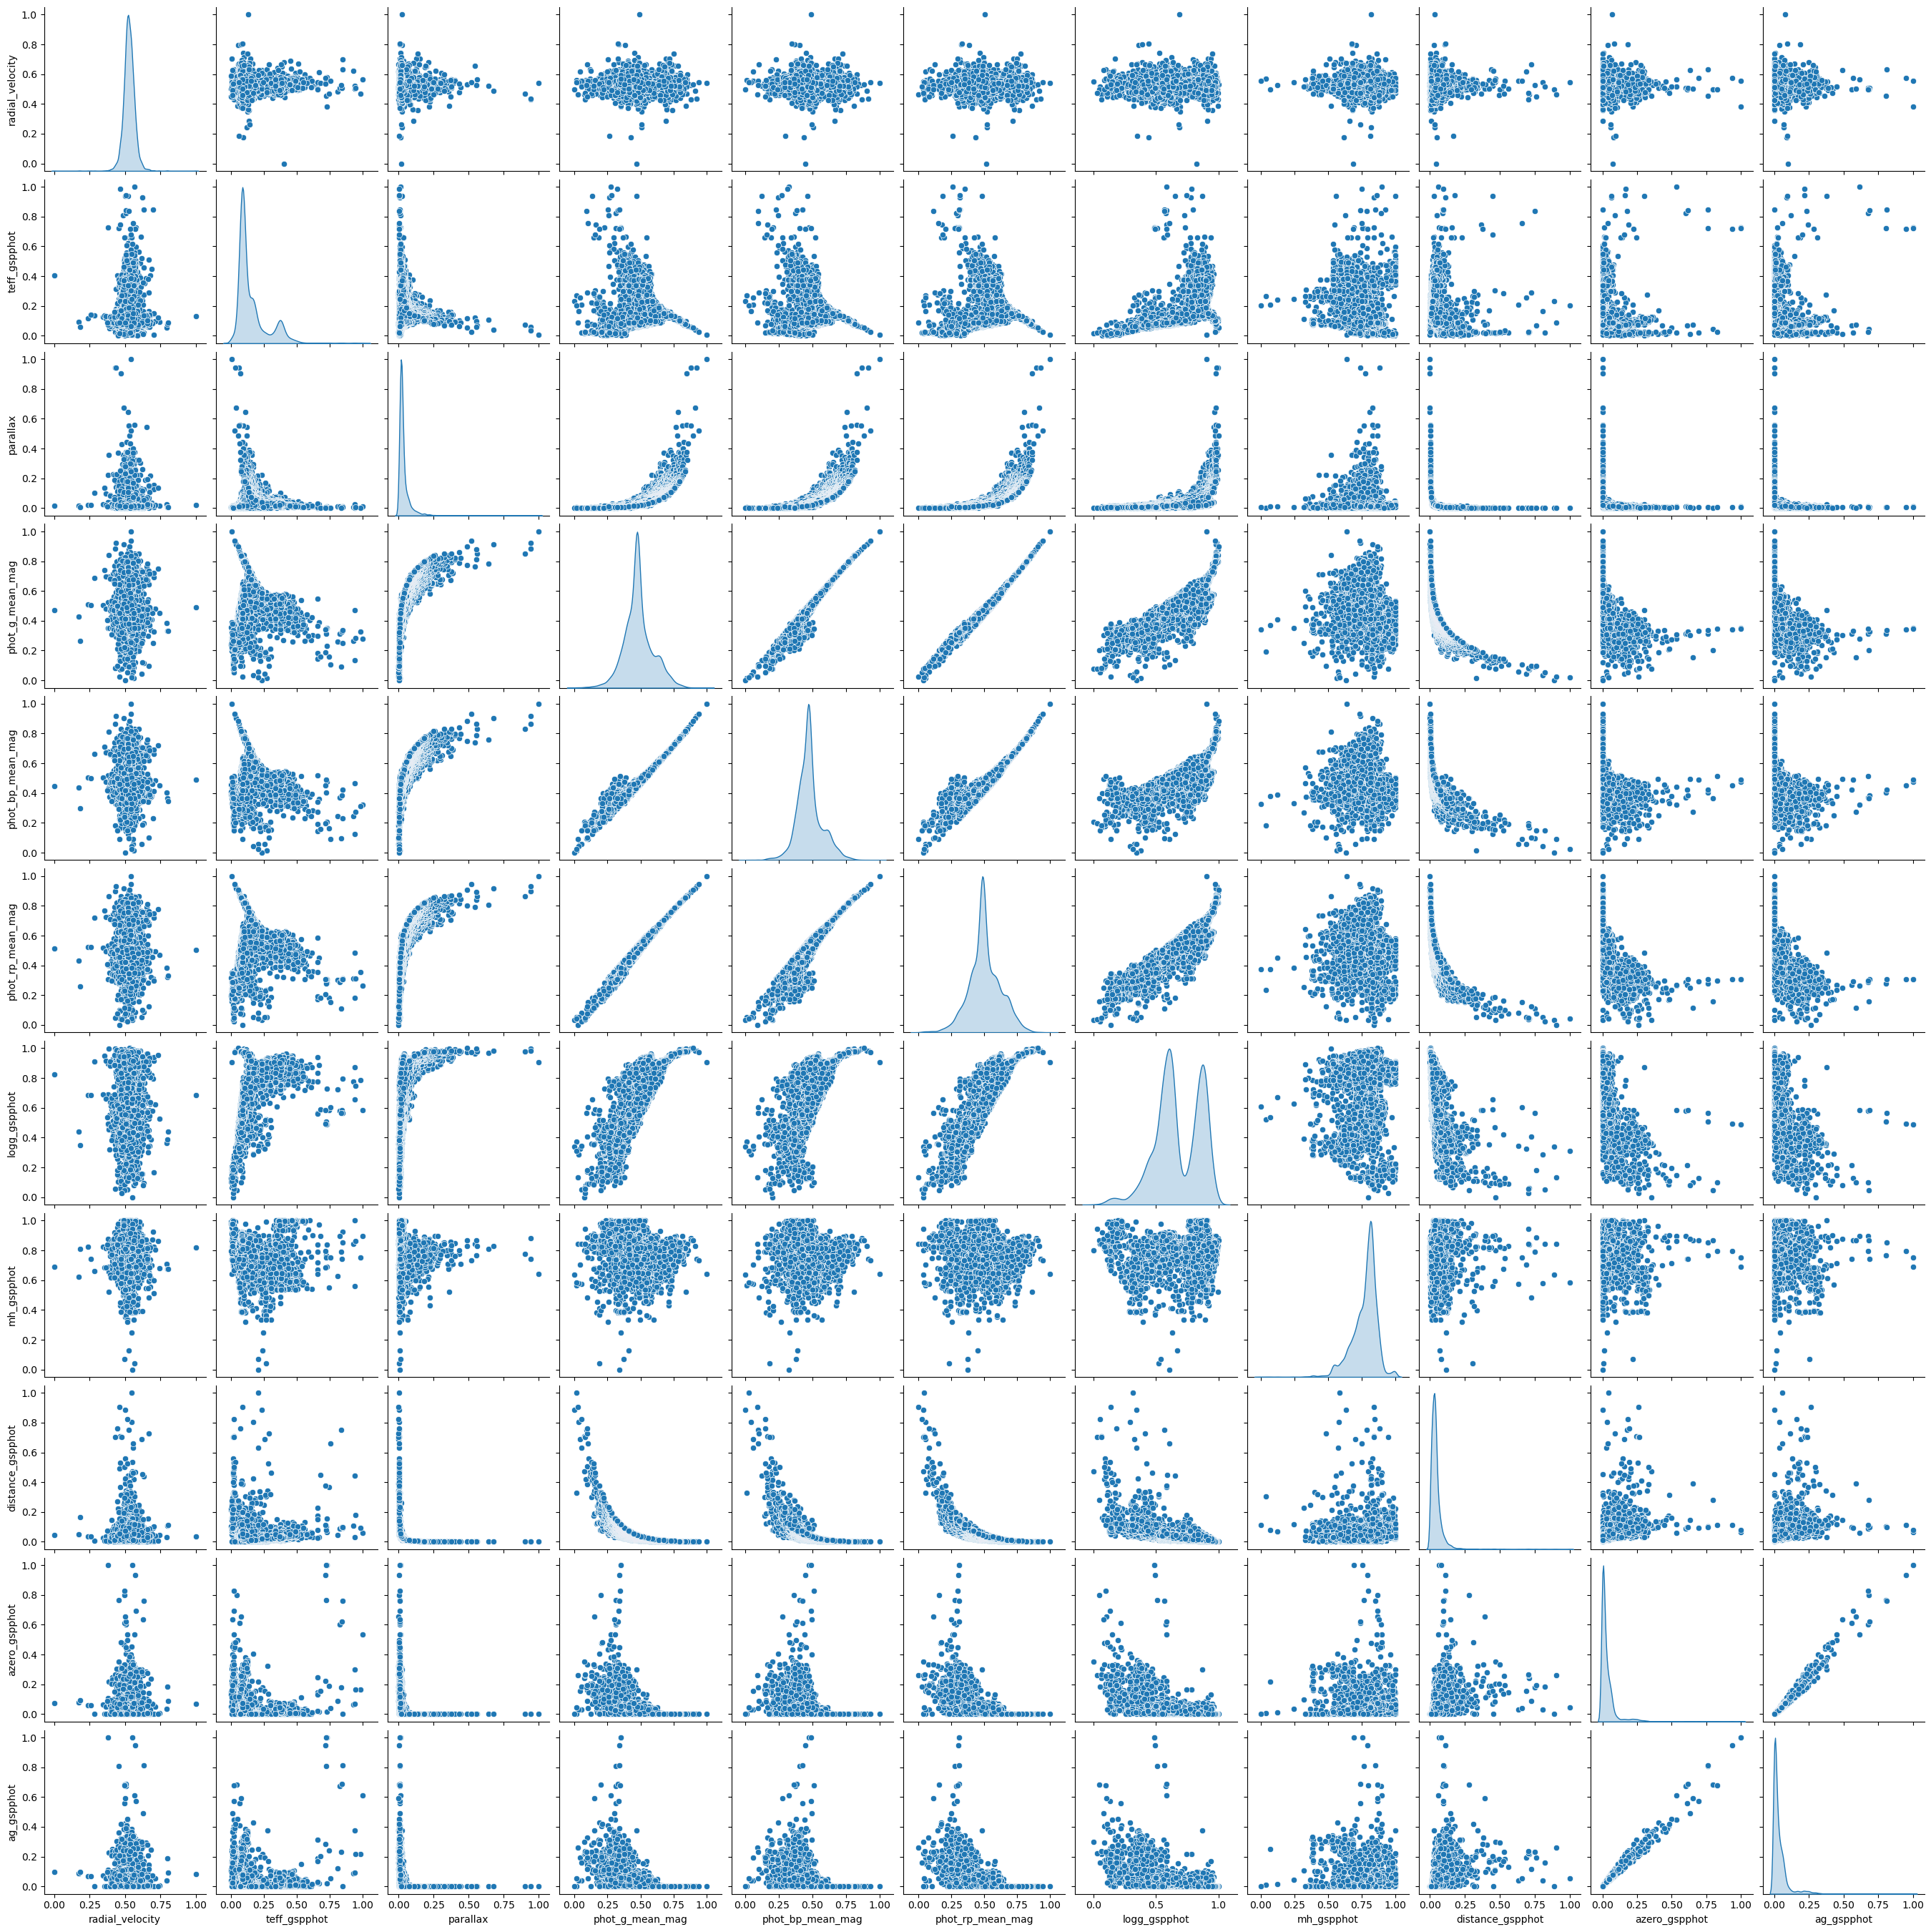

In [10]:
# minmax scaler적용
mm = MinMaxScaler()
star_df_clean_scaled = mm.fit_transform(star_df_clean)

# 결과를 DataFrame으로 변환
star_df_clean_scaled_df = pd.DataFrame(star_df_clean_scaled, columns=[col for col in star_df_clean.columns], index=star_df_clean.index)

sns.pairplot(star_df_clean_scaled_df, diag_kind='kde')
#plt.savefig('star original scatterplot matrix')
plt.show()

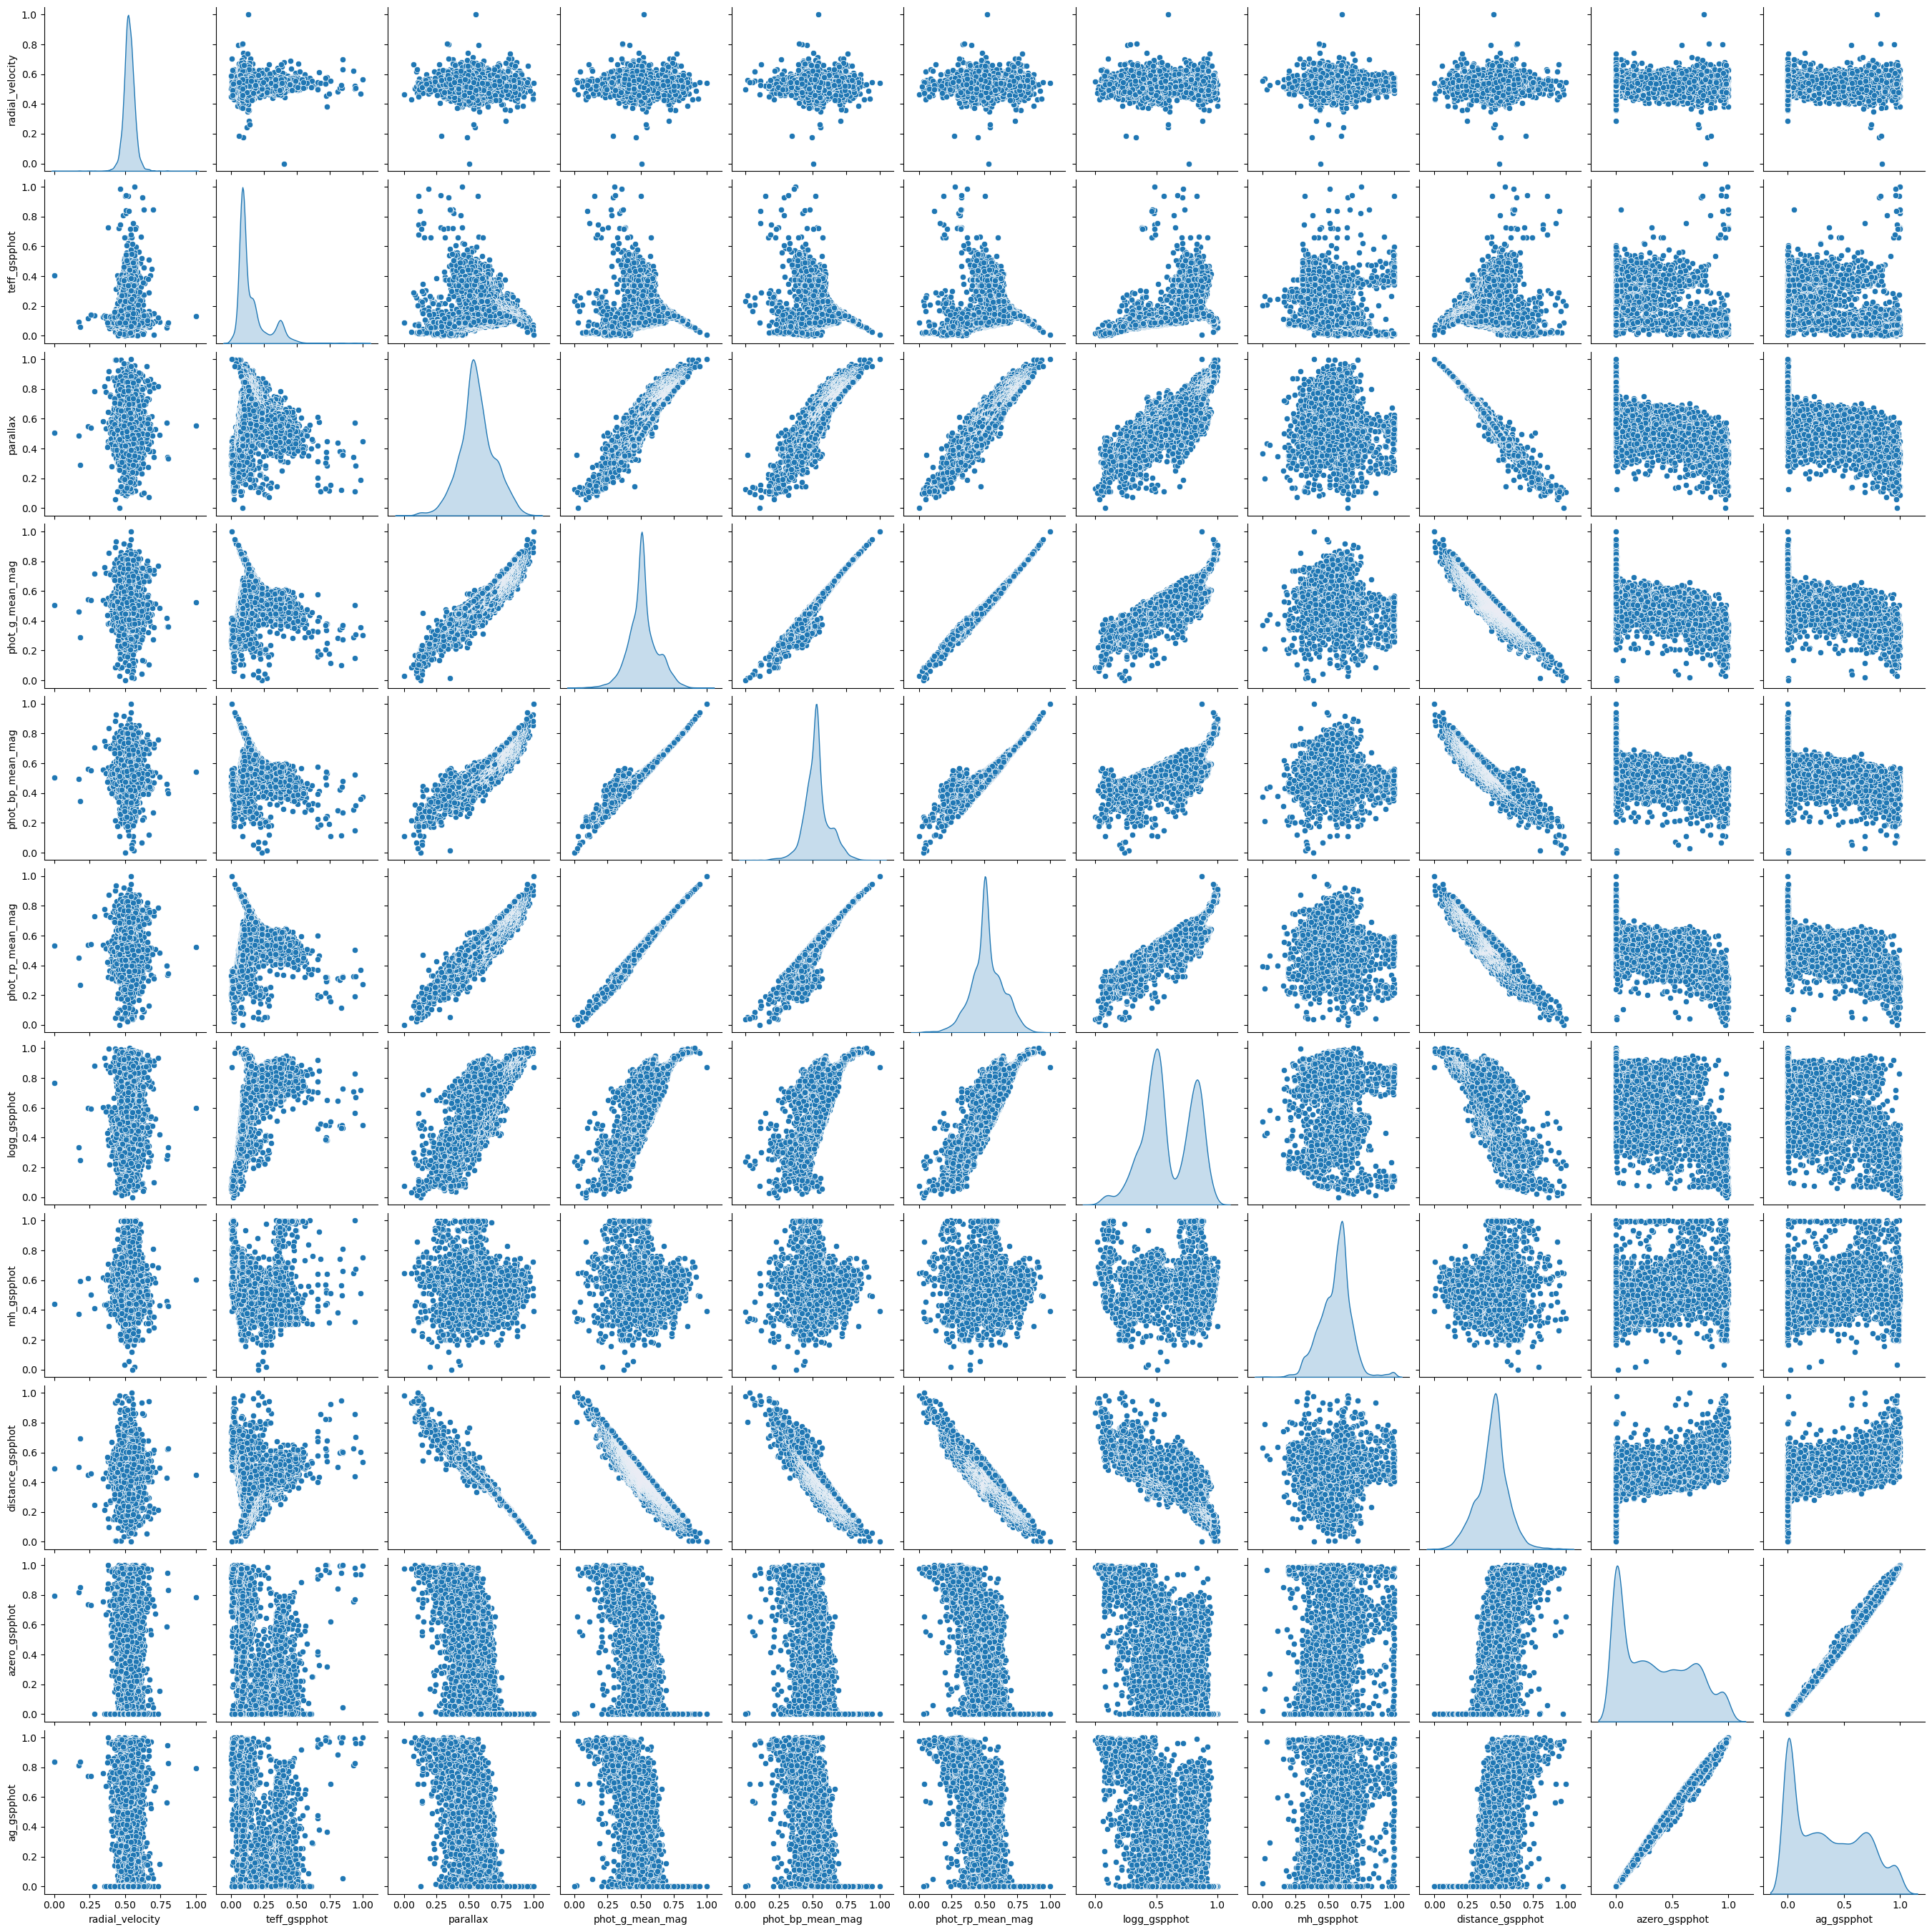

In [11]:
# minmax scaler적용
mm_yeojohnson = MinMaxScaler()
star_df_clean_scaled_yeojohnson = mm_yeojohnson.fit_transform(star_df_clean_yeojohnson)

# 결과를 DataFrame으로 변환
star_df_clean_scaled_yeojohnson_df = pd.DataFrame(star_df_clean_scaled_yeojohnson, columns=[col for col in star_df_clean_yeojohnson.columns], index=star_df_clean_yeojohnson.index)

sns.pairplot(star_df_clean_scaled_yeojohnson_df, diag_kind='kde')
#plt.savefig('star preprocessed scatterplot matrix')
plt.show()

In [12]:
from scipy.stats import pearsonr

def calculate_corr_and_pvalues(df):
    cols = df.columns
    n = len(cols)
    
    corr_matrix = pd.DataFrame(index=cols, columns=cols)
    pval_matrix = pd.DataFrame(index=cols, columns=cols)

    for i in range(n):
        for j in range(n):
            x = df[cols[i]]
            y = df[cols[j]]
            r, p = pearsonr(x, y)
            corr_matrix.iloc[i, j] = round(r, 2)    
            pval_matrix.iloc[i, j] = round(p, 3)    

    return corr_matrix.astype(float), pval_matrix.astype(float)

# 피어슨 상관계수 
corr_matrix, pval_matrix = calculate_corr_and_pvalues(star_df_clean_scaled_yeojohnson_df)

In [13]:
corr_matrix

,radial_velocity,teff_gspphot,parallax,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,logg_gspphot,mh_gspphot,distance_gspphot,azero_gspphot,ag_gspphot
radial_velocity,1.00,0.04,0.02,0.02,0.01,0.02,0.04,-0.02,-0.02,-0.07,-0.07
teff_gspphot,0.04,1.00,0.13,0.11,-0.03,0.24,0.63,-0.33,-0.11,-0.26,-0.22
parallax,0.02,0.13,1.00,0.92,0.90,0.92,0.77,-0.21,-0.99,-0.69,-0.69
phot_g_mean_mag,0.02,0.11,0.92,1.00,0.98,0.99,0.81,-0.21,-0.93,-0.67,-0.66
phot_bp_mean_mag,0.01,-0.03,0.90,0.98,1.00,0.95,0.70,-0.15,-0.91,-0.59,-0.59
phot_rp_mean_mag,0.02,0.24,0.92,0.99,0.95,1.00,0.88,-0.26,-0.93,-0.71,-0.70
logg_gspphot,0.04,0.63,0.77,0.81,0.70,0.88,1.00,-0.31,-0.77,-0.66,-0.64
mh_gspphot,-0.02,-0.33,-0.21,-0.21,-0.15,-0.26,-0.31,1.00,0.21,0.41,0.40
distance_gspphot,-0.02,-0.11,-0.99,-0.93,-0.91,-0.93,-0.77,0.21,1.00,0.68,0.68
azero_gspphot,-0.07,-0.26,-0.69,-0.67,-0.59,-0.71,-0.66,0.41,0.68,1.00,1.00
